# Task 4 – Advanced Analytics & Statistical Modeling

## Objective
Apply statistical analysis, customer segmentation and basic predictive modeling.

## Dataset
Superstore Sales Dataset

In [5]:
# Task 4 - Advanced Analytics
print("Task 4 - Advanced Analytics")

Task 4 - Advanced Analytics


In [3]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
conn = sqlite3.connect("superstore.db")

query = "SELECT * FROM Superstore"

df = pd.read_sql_query(query, conn)

conn.close()

print("Dataset loaded successfully!")
print(df.shape)
df.head()

Dataset loaded successfully!
(51290, 27)


,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [6]:
conn = sqlite3.connect("superstore.db")

query = "SELECT * FROM Superstore"

df = pd.read_sql_query(query, conn)

conn.close()

print("Dataset loaded successfully!")
print(df.shape)
df.head()

Dataset loaded successfully!
(51290, 27)


,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [7]:
print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['Category', 'City', 'Country', 'Customer ID', 'Customer Name', 'Discount', 'Market', 'ji_lu-shu', 'Order Date', 'Order ID', 'Order Priority', 'Product ID', 'Product Name', 'Profit', 'Quantity', 'Region', 'Row ID', 'Sales', 'Segment', 'Ship Date', 'Ship Mode', 'Shipping Cost', 'State', 'Sub-Category', 'Year', 'Market2', 'weeknum']


In [8]:
sales = df["Sales"].dropna()

print("Mean:", sales.mean())
print("Median:", sales.median())
print("Mode:", sales.mode()[0])
print("Standard Deviation:", sales.std())
print("Skewness:", sales.skew())

Mean: 246.49844024176252
Median: 85.0
Mode: 13
Standard Deviation: 487.5671746315864
Skewness: 8.137980509722208


In [9]:
consumer_sales = df[df["Segment"] == "Consumer"]["Sales"].dropna()
corporate_sales = df[df["Segment"] == "Corporate"]["Sales"].dropna()

t_stat, p_value = ttest_ind(
    consumer_sales,
    corporate_sales,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Significant difference between Consumer and Corporate sales.")
else:
    print("Result: No significant difference between Consumer and Corporate sales.")

T-statistic: -0.5060568346708225
P-value: 0.6128202633324272
Result: No significant difference between Consumer and Corporate sales.


In [10]:
contingency_table = pd.crosstab(
    df["Category"],
    df["Region"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

if p_value < 0.05:
    print("Result: Category and Region have a significant relationship.")
else:
    print("Result: No significant relationship between Category and Region.")

Chi-square statistic: 342.46643170812524
P-value: 4.2788151792510144e-58
Degrees of freedom: 24
Result: Category and Region have a significant relationship.


In [11]:
mean_sales = sales.mean()
std_error = stats.sem(sales)

confidence_interval = stats.t.interval(
    0.95,
    len(sales) - 1,
    loc=mean_sales,
    scale=std_error
)

print("Mean Sales:", mean_sales)
print("95% Confidence Interval:")
print(confidence_interval)

Mean Sales: 246.49844024176252
95% Confidence Interval:
(np.float64(242.2787900490432), np.float64(250.71809043448184))


In [12]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Order Date"].min(), df["Order Date"].max()

(Timestamp('2026-08-11 00:00:00'), Timestamp('2026-08-11 00:00:00'))

In [13]:
monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
)

monthly_sales.head()

Order Date
2026-08-31    12642905
Freq: ME, Name: Sales, dtype: int64

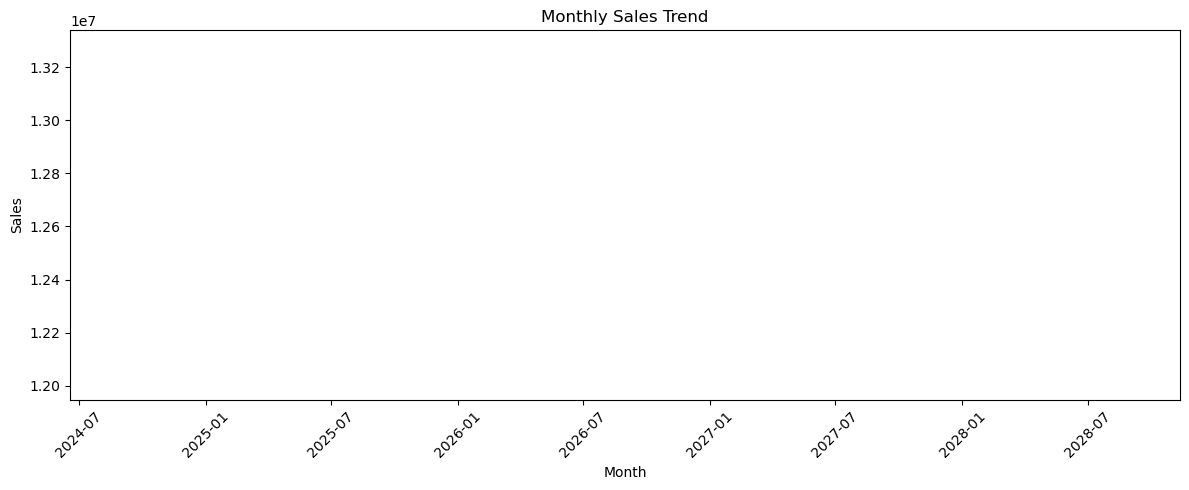

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
customer_data = df.groupby("Customer ID").agg({
    "Sales": "sum",
    "Quantity": "sum",
    "Profit": "sum"
}).reset_index()

customer_data.head()

,Customer ID,Sales,Quantity,Profit
0,AA-103151,1445,44,12.8760
1,AA-103152,6105,50,568.7370
2,AA-103153,633,21,228.9600
3,AA-103154,5565,30,-362.8825
4,AA-103751,2407,35,577.9350


In [16]:
features = customer_data[
    ["Sales", "Quantity", "Profit"]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

print("Features standardized successfully!")

Features standardized successfully!


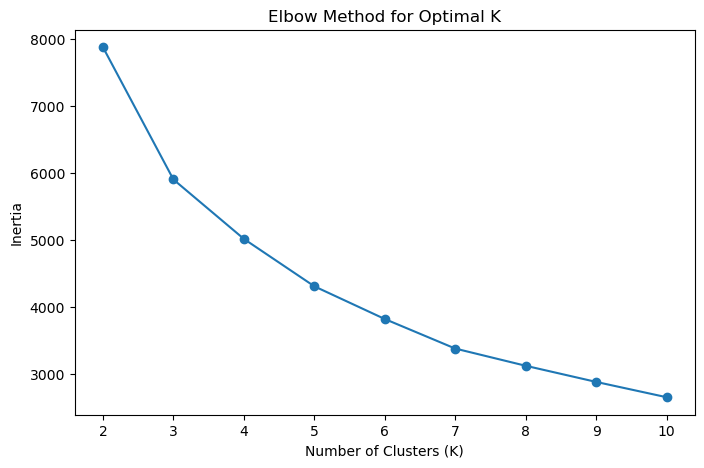

In [19]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [20]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_data["Cluster"] = kmeans.fit_predict(scaled_features)

customer_data.head()

,Customer ID,Sales,Quantity,Profit,Cluster
0,AA-103151,1445,44,12.8760,1
1,AA-103152,6105,50,568.7370,1
2,AA-103153,633,21,228.9600,0
3,AA-103154,5565,30,-362.8825,3
4,AA-103751,2407,35,577.9350,1


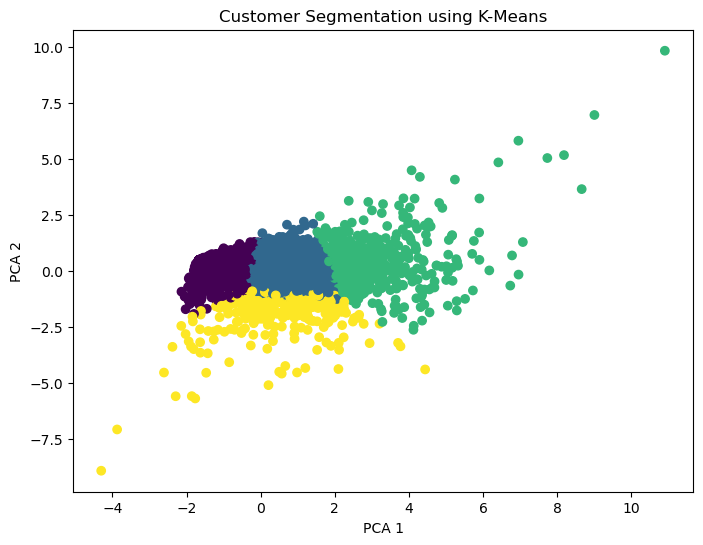

In [21]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_features)

customer_data["PCA1"] = pca_result[:, 0]
customer_data["PCA2"] = pca_result[:, 1]

plt.figure(figsize=(8, 6))

plt.scatter(
    customer_data["PCA1"],
    customer_data["PCA2"],
    c=customer_data["Cluster"]
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [22]:
cluster_profile = customer_data.groupby("Cluster").agg({
    "Sales": "mean",
    "Quantity": "mean",
    "Profit": "mean",
    "Customer ID": "count"
})

cluster_profile

,Sales,Quantity,Profit,Customer ID
Cluster,,,,
0,858.637795,15.829673,49.847081,2413
1,3205.524783,48.565675,512.303421,1614
2,7679.505112,77.423313,1483.928183,489
3,4599.487395,66.862745,-575.132543,357


In [23]:
model_data = df[
    ["Quantity", "Discount", "Sales"]
].dropna()

X = model_data[
    ["Quantity", "Discount"]
]

y = model_data["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (41032, 2)
Testing data: (10258, 2)


In [24]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


In [26]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 241.9766287730923
RMSE: 497.0449939572206
R² Score: 0.09445447016624686


In [27]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

feature_importance

,Feature,Coefficient
0,Quantity,66.353844
1,Discount,-194.123041


In [28]:
feature_importance = feature_importance.sort_values(
    by="Coefficient",
    key=lambda x: x.abs(),
    ascending=False
)

print("Top 3 Important Features:")
print(feature_importance.head(3))

Top 3 Important Features:
    Feature  Coefficient
1  Discount  -194.123041
0  Quantity    66.353844


In [29]:
print("TASK 4 - KEY FINDINGS")
print("----------------------")
print("1. Discount has the strongest influence on Sales.")
print("2. Quantity has a positive influence on Sales.")
print("3. Increasing Quantity is associated with higher Sales.")
print("4. Higher Discount is associated with lower Sales in this model.")
print("5. These results can help in pricing and sales strategy decisions.")

TASK 4 - KEY FINDINGS
----------------------
1. Discount has the strongest influence on Sales.
2. Quantity has a positive influence on Sales.
3. Increasing Quantity is associated with higher Sales.
4. Higher Discount is associated with lower Sales in this model.
5. These results can help in pricing and sales strategy decisions.


In [ ]:
]

